## Εργασία 1 ##

Καλωσήρθατε στην πρώτη σας εργασία. Η εργασία αυτή έχει σκοπό να σας βοηθήσει να εμπεδώσετε τα γραμμικά μοντέλα.

Τα Jupyter Notebooks είναι αλληλεπιδραστικά περιβάλλοντα προγραμματισμού ενσωματωμένα σε μια ιστοσελίδα. Στο μάθημα "Μηχανική Μάθηση" τα χρησιμοποιούμε στο πρακτικό μέρος του μαθήματος.

Στην εργασία αυτή θα πρέπει να συμπληρώσετε κώδικα Python 3 στα σημεία που αναφέρουν # YOUR CODE HERE. Μην τροποποιείτε τον κώδικα που βρίσκεται εκτός αυτών των περιοχών.

Πρωτού παραδόσετε την εργασία σας σιγουρευτείτε ότι ο κώδικας σε όλα τα κελιά τρέχει σωστά. Για το σκοπό αυτό επιλέξτε από το μενού **Χρόνος εκτέλεσης (runtime) -> Επανεκίνηση περιόδου λειτουργίας και εκτέλεση όλων**.

Συμπληρώστε το όνομα (**NAME**) και το **AEM** σας παρακάτω:

In [1]:
NAME = "Βλαχάκης Θεόδωρος"
AEM = "10476"

## Μέρος Α: 5 μονάδες ##

Σε αυτό το μέρος της άσκησης θα χτίσουμε ένα μοντέλο γραμμικής παλινδρόμησης από το μηδέν.

**Α1 (1 μονάδα):** Υλοποιήστε τη σιγμοειδή συνάρτηση $\sigma(z)= \dfrac{1}{1 + exp(-z)}$ με τη NumPy.

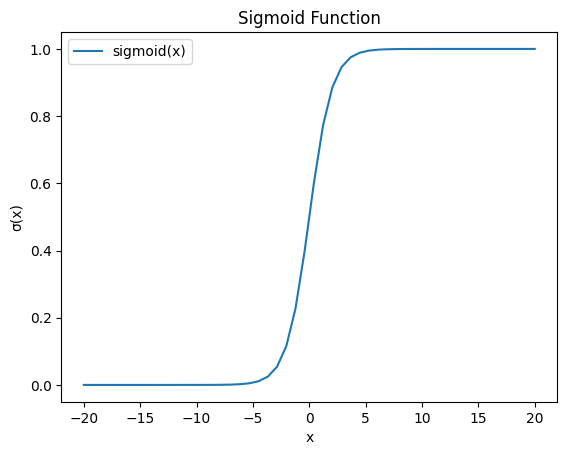

In [2]:
import numpy as np

def sigmoid(z):
    """Υπολογίζει τη σιγμοειδή συνάρτηση."""
    return 1 / (1 + np.exp(-z))

import matplotlib.pyplot as plt
x = np.linspace(-20, 20, 50)
y = sigmoid(x)
plt.plot(x, y, label="sigmoid(x)")
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.title("Sigmoid Function")
plt.legend()
plt.show()


In [3]:
"""Τεστ ορθού υπολογισμού σιγμοειδούς."""
assert sigmoid(0) == 0.5
assert np.round(sigmoid(7),8) == 0.99908895
assert np.round(sigmoid(-1),8) == 0.26894142

**Α2 (4 μονάδες):** Υλοποιήστε κλάση για τον αλγόριθμο της λογιστικής παλινδρόμησης. Αρχικοποιήστε τις παραμέτρους σε μηδενικές τιμές. Αποθηκεύστε τες στο διάνυσμα στήλη theta. Η συνάρτηση fit πρέπει να δέχεται πίνακα X με τις τιμές των μεταβλητών εισόδου και διάνυσμα στήλη y με τις τιμές της μεταβλητής εξόδου. Η συνάρτηση predict πρέπει να δέχεται πίνακα Χ με τις τιμές των μεταβλητών εισόδου.

In [5]:
class MyLogisticRegression:
    def __init__(self, num_iterations=2000, learning_rate=0.004):
      self.theta = None
      self.num_iterations = num_iterations
      self.learning_rate = learning_rate

    def fit(self, X, y):
        # Check if the shapes of the data training set X and the values y of the output variable are correct
        if (X.ndim != 2):
            raise ValueError("X must be a 2D array")
        if (y.ndim !=2 and y.ndim !=1):
            raise ValueError("y must be a 1D or 2D array")
        if (y.ndim == 2 and y.shape[1] !=1):
            raise ValueError("y is a 2D array but not a column vector with a shape like (n,1)")
        if (X.shape[0] != y.shape[0]):
            raise ValueError("The number of training instances do not match the number of values of the target variable in training set")
        
        m = X.shape[0]
        n = X.shape[1]

        # Initialization of theta parameters to a zeros column vector
        self.theta = np.zeros((n + 1, 1))

        # Add the predefined input x0=1 to all the examples in the training set, which is necessary to compute the intercept.
        X = np.concatenate((np.ones((m, 1)), X), axis=1)
        
        # Use the "gradient descent", adapted for logistic regression, as searching alogrithm to find the optimal values for theta parameters.
        # Run the algorithm for a specific number of iterations and update the theta values in each itearation.
        for _ in range(self.num_iterations):
            self.theta = self.theta - self.learning_rate * (1/m) * X.T @ (sigmoid(X @ self.theta) - y)

    def predict(self, X):
        X = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)

        # Compute the probability for each instance of X to belong to the class "1", that is, the probability that the actual "y" value that
        # corresponds to this instance is equal to 1.
        # Reminder: the output of the model that logistic regression computes is defined by sigmoid function.
        probabilities = sigmoid(X @ self.theta)

        predictions = (probabilities >= 0.5).astype(int)

        return predictions


In [6]:
"""Τεστ ορθής λειτουργίας fit"""
from sklearn.datasets import make_blobs

# δημιουργία δύο ομάδων από τυχαία σημεία με κέντρο 0,0,0 και 3,3,3 και τυπική απόκλιση 1
centers = [[0.0, 0.0, 0.0], [3.0, 3.0, 3.0]]
X, y = make_blobs(n_samples=200, centers=centers,
                  random_state=47, shuffle=False)
y = np.array(y).reshape(-1,1)

lr = MyLogisticRegression()
lr.fit(X, y)

assert np.allclose(lr.theta, np.array([[-1.1772064],[0.5026043],[0.40811666],[0.55685573]]))

In [7]:
"""Τεστ ορθής λειτουργίας predict"""
from sklearn.datasets import make_blobs

# δημιουργία δύο ομάδων από τυχαία σημεία με κέντρο 0,0,0 και 3,3,3 και τυπική απόκλιση 1
centers = [[0.0, 0.0, 0.0], [3.0, 3.0, 3.0]]
X, y = make_blobs(n_samples=200, centers=centers,
                  random_state=47, shuffle=False)
y = np.array(y).reshape(-1,1)

lr = MyLogisticRegression()
lr.fit(X, y)

assert np.allclose(lr.predict(X[[0,199],:]), np.array([[0],[1]]))

## Μέρος B: Χρήση μοντέλου στο σύνολο digits (3 μονάδες)

Σε αυτό το μέρος θα δουλέψουμε με το σύνολο δεδομένων digits (https://scikit-learn.org/stable/datasets/toy_dataset.html#digits-dataset), το οποίο αφορά μια εργασία αναγνώρισης ψηφίων (0 έως 9) από δυαδικές εικόνες  διαστάσεων 32x32 με χειρόγραφα ψηφία, οι οποίες χωρίστηκαν σε 64 (8x8) τμήματα των 4x4 δυαδικών στοιχείων, και σε κάθε ένα από αυτά τα 64 τμήματα μετρήθηκαν πόσα από τα 16 (4x4) στοιχεία είχε τιμή 1.

Αρχικά θα φορτώσουμε τα δεδομένα

In [8]:
from sklearn.datasets import load_digits
digits = load_digits()
X = digits.data
y = digits.target

**Β1 (1 μονάδα)**: Χρησιμοποιήστε την κλάση OneVsOneClαssifier της sklearn σε συνδυασμό με την κλάση LogisticRegression για να εκπαιδεύσετε ένα μοντέλο λογιστικής παλινδρόμησης για κάθε ζεύγος κλάσης. Χρησιμοποιήστε προκαθορισμένες ρυθμίσεις στις παραμέτρους της κλάσης LogisticRegression, αλλά θέστε τον μέγιστο αριθμό επαναλήψεων σε 1000 και την παράμετρο random_state σε 42. Ονομάστε ovo το αντικείμενο της κλάσης.

In [9]:
from sklearn.multiclass import OneVsOneClassifier
from sklearn.linear_model import LogisticRegression

# Construct an object of the class OneVsOneClassifier.
# Also, set the estimators used for predictions to be objects from Logistic Regression class.
# Each estimator represents a Logistic Regression approach to solve a binary classification problem.
# Each estimator refers to a specific set of classes and it uses Logistic Regression to answer this binary problem:
# The given training instance belongs to the first class to which the estimator refers or not (which means that it belogns to the second) ?

ovo = OneVsOneClassifier(LogisticRegression(max_iter=1000, random_state=42))
ovo.fit(X, y)

# Make predictions with the model created
predictions = ovo.predict(X)
accuracy = ovo.score(X, y)
print("The proportion of accuracy is:", accuracy*100, "%")
if (np.allclose(predictions, y, atol=0.01)):
    print("All predictions are correct")
else:
    print("There are predictions that are not correct")


The proportion of accuracy is: 100.0 %
All predictions are correct


In [10]:
#έλεγχος ορθής λειτουργίας
assert len(ovo.estimators_) == 45
assert ovo.estimators_[0].coef_.shape == (1, 64)

**Β2 (0,5 μονάδες)**: Χρησιμοποιήστε την κλάση OneVsRestClαssifier της sklearn σε συνδυασμό με την κλάση LogisticRegression για να εκπαιδεύσετε ένα μοντέλο λογιστικής παλινδρόμησης για κάθε κλάση. Χρησιμοποιήστε προκαθορισμένες ρυθμίσεις στις παραμέτρους της κλάσης LogisticRegression, αλλά θέστε τον μέγιστο αριθμό επαναλήψεων σε 1000 και την παράμετρο random_state σε 42. Ονομάστε ovr το αντικείμενο της κλάσης.

In [11]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

# Construct an object of the class OneVsRestClassifier.
# Also, set the estimators used for predictions to be objects from Logistic Regression class.
# Each estimator represents a Logistic Regression approach to solve a binary classification problem.
# Each estimator refers to a specific class and it uses Logistic Regression to answer this binary problem:
# The given training instance belongs to the class to which the estimator refers or not ?

ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
ovr.fit(X, y)

# Make predictions with the model created
predictions = ovr.predict(X)
accuracy = ovr.score(X, y)
print("The proportion of accuracy is:", accuracy*100, "%")
if (np.allclose(predictions, y, atol=0.01)):
    print("All predictions are correct")
else:
    print("There are predictions that are not correct")

The proportion of accuracy is: 99.77740678909294 %
There are predictions that are not correct


In [12]:
#έλεγχος ορθής λειτουργίας
assert len(ovr.estimators_) == 10
assert ovr.estimators_[0].coef_.shape == (1, 64)

**Β3 (1 μονάδα)**: Ορίστε συνάρτηση που δέχεται ένα μοντέλο, και ένα σύνολο δεδομένων, συγκρίνει τις πραγματικές τιμές της μεταβλητής εξόδου με τις προβλέψεις του μοντέλου χρησιμοποιώντας τη συνάρτηση predict του μοντέλου και επιστρέφει τους δείκτες των παραδειγμάτων τα οποία το μοντέλο ταξινομεί εσφαλμένα.

In [13]:
def find_misclassified(classifier, input, output):
  """
  The function find_classifier takes as input a model, that is, a classifier which is used to solve a macihine learing problem,
  a data training set and the actual values of the output varialble in this training set.

  The fucnction compares the actual values of the output variable with the predictions made by the model using its predict function.
  
  Returns the indices of the training examples that the model misclassifies."
  
  """
  
  # Check if the shapes of the data training set X and the values y of the output variable are correct
  if (input.ndim != 2):
      raise ValueError("input values must be a 2D array")
  if (output.ndim !=2 and y.ndim !=1):
      raise ValueError("output values must be a 1D or 2D array")
  if (output.ndim == 2 and output.shape[1] !=1):
      raise ValueError("output values is a 2D array but not a column vector with a shape like (n,1)")
  if (input.shape[0] != output.shape[0]):
      raise ValueError("The number of training instances do not match the number of values of the target variable in training set")
  
  predictions = classifier.predict(input)

  misclassified_examples_indices = np.where(predictions != output)[0]

  return misclassified_examples_indices

In [14]:
#έλεγχος ορθής λειτουργίας
output = find_misclassified(ovr, X, y)
expected = np.array([524, 890, 1553, 1658])
np.testing.assert_array_equal(output, expected)

Μια εικόνα που δεν τα πάει καλά το μοντέλο είναι η 525η με δείκτη 524. Το μοντέλο προβλέπει τον αριθμό 3, ενώ η εικόνα (υποτίθεται ότι) απεικονίζει τον αριθμό 8.

In [15]:
print(ovr.predict(X[524:525]))
print(y[524:525])

[3]
[8]


Εμφανίζοντας την εικόνα μπορούμε να διαπιστώσουμε γιατί δυσκολεύεται το μοντέλο με τα ίδια μας τα μάτια.

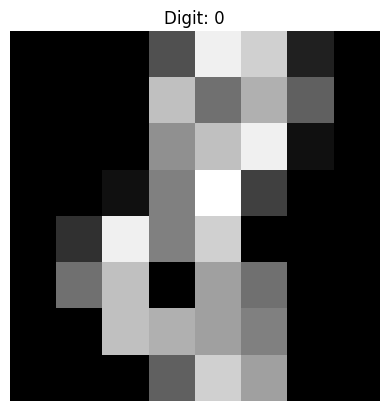

In [16]:
from matplotlib import pyplot as plt

image = digits.images[524]

# Plot the image
plt.imshow(image, cmap='gray')
plt.title(f'Digit: {digits.target[0]}')  # Show the corresponding label
plt.axis('off')  # Turn off the axis labels
plt.show()

**Β4 (0,5 μονάδες)**: Τέλος χρησιμοποιήστε την κλάση LogisticRegression απο μόνη της για να εκπαιδεύσετε ένα μοντέλο πολυχοτομικής λογιστικής παλινδρόμησης. Χρησιμοποιήστε προκαθορισμένες ρυθμίσεις στις παραμέτρους της κλάσης LogisticRegression, αλλά θέστε τον μέγιστο αριθμό επαναλήψεων σε 1000 και την παράμετρο random_state σε 42. Ονομάστε clf το αντικείμενο της κλάσης.

In [17]:
# Multiclass problem approach. Use LogisticRegression to do multinomial logistic regression

from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=42, solver='newton-cg', max_iter=1000, multi_class='multinomial')

clf.fit(X, y)

# Find the misclassified training examples that could not be predicted well by the model of multinomial logistic regression
misclassified_examples_idx = find_misclassified(clf, X, y)

accuracy = len(misclassified_examples_idx) / len(y)
print("The proportion of predictions accuracy is:", accuracy*100, "%")

c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The proportion of predictions accuracy is: 0.0 %


In [18]:
#έλεγχος ορθής λειτουργίας
assert clf.coef_.shape == (10, 64)

## Μέρος Γ: Χρήση μοντέλου στο σύνολο breast cancer (2 μονάδες)

Σε αυτό το μέρος θα δουλέψουμε με το σύνολο δεδομένων breast cancer (https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset), το οποίο αφορά την ταξινόμηση ψηφιακών εικόνων μικροσκοπίου με κύτταρα που έχουν εξαχθεί από μαστό μέσω βιοψίας με λεπτή βελόνα.

In [19]:
from sklearn.datasets import load_breast_cancer
bca = load_breast_cancer()
X = bca.data
y = bca.target

**Γ1 (1 μονάδα)**: Επειδή τα εύρη τιμών των μεταβλητών διαφέρουν, εφαρμόστε προτυποποίηση στα δεδομένα εισόδου.

In [20]:
def data_standardization(X):
    """
    This function standardizes a given dataset X.

    The function can handle input data in two forms:  
    - A 2D array representing a training dataset with multiple features.  
    - A 1D array representing a single variable's values (e.g., a target variable).  
    *If the input is a 1D array, it is reshaped into a 2D column vector to ensure consistency in processing.  
    
    The function calculates the mean and standard deviation for each column of the dataset.  

    Standardization is performed using the formula:  
        standardized_X = (X - mean) / standard_deviation  
    If the standard deviation of a column is zero , i.e no variance exists for the values of this column, the function avoids division
    by zero by setting it to 1.  

    The function returns the standardized dataset, the mean values, and the standard deviations used in the transformation.  
    """

    if(X.ndim == 1):
        # This means that the input is a 1D array, so the function transforms it into a column vector
        X = np.array(X).reshape(-1, 1)

    data_mean_values = np.array(np.mean(X, axis=0)).reshape(1, -1)
    data_standard_deviations = np.array(np.std(X, axis=0)).reshape(1,-1)
    standardized_X = ( X - data_mean_values ) / np.where(data_standard_deviations == 0, 1, data_standard_deviations)
    
    return standardized_X, data_mean_values, data_standard_deviations

# print(X.shape)
X, X_mean_values, X_standard_deviations = data_standardization(X)
# y1, y_mean_values, y_standard_deviations = data_standardization(y)
# print(X_mean_values[:10])
# print(X_standard_deviations[:10])
# print(X1.shape)
# print(np.mean(X1, axis=0)[:10])
# print(np.std(X1, axis=0)[:10].shape)
#assert np.allclose(np.std(X, axis=0), np.ones(30), atol=0.01)

In [21]:
#έλεγχος ορθής λειτουργίας
assert np.allclose(np.mean(X,axis=0), np.zeros(30), atol=0.01)

Παρακάτω εκπαιδεύουμε ένα μοντέλο λογιστικής παλινδρόμησης με προκαθορισμένες ρυθμίσεις στις παραμέτρους και παράμετρο random_state ίση με 42.

In [22]:
clf = LogisticRegression(random_state=42)
clf.fit(X,y)

LogisticRegression(random_state=42)

**Γ2 (1 μονάδα)**: Υλοποιήστε συνάρτηση που δέχεται μοντέλο λογιστικής παλινδρόμησης δυαδικής ταξινόμησης σαν το παραπάνω καθώς και πίνακα συμβολοσειρών με τα ονόματα των μεταβλητών εισόδου και επιστρέφει τη σημαντικότερη μεταβλητή εισόδου.

In [23]:
def best_feature(model, feature_names):
    """
    The function best_feature finds the most import input variable (i.e feature) and returns its name.

    The function takes two input parameters:
    - A logistic regression model which is trained to data set in order to deal with a binary classification problem.
    - An array of strings which includes the names of the input variables (i.e the features) of the data set to which the model has been trained.

    The function finds the most important feature in the training set to which the model is trained. The most important feature is the one that
    it has the greatest in absolute value coefficient in the linear model computed by the the logistic regression algorithm. This is defined as
    "most important" because any variation to it has the greatest impact on the model output.
    The function returns the name of this feature stored in the input array of strings.
    """
    
    most_important_feture_idx = np.argmax(np.absolute(model.coef_))
    return feature_names[most_important_feture_idx]

In [24]:
#έλεγχος ορθής λειτουργίας
assert best_feature(clf, bca.feature_names) == 'worst texture'